In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
df=pd.read_csv('student_performance.csv')

In [ ]:
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded: 30 students, 13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    index=False,
    if_exists='replace'
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database 'college_db' created successfully")
print(f"Table 'students' has {count} rows")


Database 'college_db' created successfully
Table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()
print("Table structure of 'students':")
print(f"{'Column Name' :<25} {'Data Type' :<12}")
print("-" * 38)
for col in columns_info:
  print(f"{col[1]:<25} {col[2]:<12}")

Table structure of 'students':
Column Name               Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result
print("Helper function 'run-query' defined successfully")
print("Usage:reun_query(sql_string,description_label")

Helper function 'run-query' defined successfully
Usage:reun_query(sql_string,description_label


In [ ]:
query1="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
LIMIT 10
"""
result1=run_query(query1,"Query 1:First 10 students(SELECT+LIMIT)")




 Query 1:First 10 students(SELECT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
ORDER BY student_id DESC
LIMIT 5
"""
result1=run_query(query1,"Query 2:Last 5 students(SELECT+LIMIT)")


 Query 2:Last 5 students(SELECT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query3="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
result1=run_query(query1,"Query 2:Last 5 maths_score(SELECT+LIMIT)")


 Query 2:Last 5 maths_score(SELECT+LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query1="""
SELECT student_id,name,department,programming_score
FROM students
WHERE programming_score BETWEEN 50 AND 75
ORDER BY student_id
"""
result1=run_query(query1,"Query 1:The List of students between 50 and 75")


 Query 1:The List of students between 50 and 75
 student_id          name  department  programming_score
       1003   Rohit Verma Electronics                 55
       1006   Meera Joshi Electronics                 52
       1011   Vikram Iyer Electronics                 72
       1014 Kavya Nambiar  Mechanical                 51
       1016  Ritu Agarwal Electronics                 69
       1021 Harish Pillai Electronics                 58
       1024 Preeti Saxena  Mechanical                 53
       1026    Rekha Nair Electronics                 63
       1029    Nitin Jain  Mechanical                 50


In [ ]:
query2="""
SELECT student_id,math_score,science_score,name,department,programming_score
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result1=run_query(query2,"Query")


 Query
 student_id  math_score  science_score           name       department  programming_score
       1010          95             89     Ananya Das Computer Science                 97
       1022          93             90    Tanvi Mehta Computer Science                 96
       1005          92             88     Arjun Nair Computer Science                 95
       1030          91             93 Akanksha Yadav Computer Science                 94
       1008          88             91    Divya Singh Computer Science                 93
       1018          90             87 Swati Kulkarni Computer Science                 92
       1001          85             78   Aarav Sharma Computer Science                 91
       1025          86             82      Amit Bose Computer Science                 89
       1013          83             86     Suresh Rao Computer Science                 88
       1027          84             79  Gaurav Shukla Computer Science                 87
  

In [ ]:
query3="""
SELECT department From students
GROUP BY department
"""
result1=run_query(query3,"Query")



 Query
      department
           Civil
Computer Science
     Electronics
      Mechanical


In [ ]:
query_top_scorers = """
SELECT student_id, name, department, programming_score
FROM students
WHERE department IN ('Computer Science', 'Electronics', 'Mechanical')
ORDER BY programming_score DESC, department, name
LIMIT 1
"""
run_query(query_top_scorers, "Top programming scorer")


 Top programming scorer
 student_id       name       department  programming_score
       1010 Ananya Das Computer Science                 97


,student_id,name,department,programming_score
0,1010,Ananya Das,Computer Science,97


In [ ]:
query_low_attendance = """
SELECT student_id, name, department, attendance_percentage
FROM students
WHERE attendance_percentage < 50
ORDER BY attendance_percentage DESC
"""
run_query(query_low_attendance, "Students with attendance percentage less than 50")


 Students with attendance percentage less than 50
Empty DataFrame
Columns: [student_id, name, department, attendance_percentage]
Index: []


,student_id,name,department,attendance_percentage


In [ ]:
query3 = """
SELECT student_id, name, department, attendance_percentage, math_score, science_score, english_score, programming_score
FROM students
WHERE attendance_percentage >= 50
ORDER BY attendance_percentage DESC, name
"""
run_query(query3, "attendace")


 attendace
 student_id           name       department  attendance_percentage  math_score  science_score  english_score  programming_score
       1010     Ananya Das Computer Science                     98          95             89             90                 97
       1022    Tanvi Mehta Computer Science                     97          93             90             88                 96
       1008    Divya Singh Computer Science                     96          88             91             84                 93
       1030 Akanksha Yadav Computer Science                     95          91             93             87                 94
       1004    Sneha Reddy       Mechanical                     95          70             80             75                 48
       1018 Swati Kulkarni Computer Science                     94          90             87             85                 92
       1016   Ritu Agarwal      Electronics                     93          87             8

,student_id,name,department,attendance_percentage,math_score,science_score,english_score,programming_score
0,1010,Ananya Das,Computer Science,98,95,89,90,97
1,1022,Tanvi Mehta,Computer Science,97,93,90,88,96
2,1008,Divya Singh,Computer Science,96,88,91,84,93
3,1030,Akanksha Yadav,Computer Science,95,91,93,87,94
4,1004,Sneha Reddy,Mechanical,95,70,80,75,48
5,1018,Swati Kulkarni,Computer Science,94,90,87,85,92
6,1016,Ritu Agarwal,Electronics,93,87,83,86,69
7,1001,Aarav Sharma,Computer Science,92,85,78,72,91
8,1025,Amit Bose,Computer Science,91,86,82,79,89
9,1014,Kavya Nambiar,Mechanical,91,74,78,82,51


In [ ]:
import pandas as pd
import sqlite3
conn = sqlite3.connect('college.db')
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established':[1990,1995,2000,2005],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,index=False,if_exists='replace')
print(dept_df.to_string(index=False))
dept_map={
    'CS':'Computer Science',
    'EC':'Electronics',
    'ME':'Mechanical',
    'CE':'Civil'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,index=False,if_exists='replace')
print("\nUpdated students list with deot_code column")


dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1990      60
       EC      Electronics  Dr.Reddy         1995      60
       ME       Mechanical  Dr.Patel         2000      60
       CE            Civil  Dr.Kumar         2005      60

Updated students list with deot_code column


In [ ]:
query_join="""
SELECT
s.name,
s.math_score,
d.dept_name,
d.hod_name,
d.established
FROM students s
INNER JOIN departments AS d ON s.dept_code=d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""
result=run_query(query_join,"Query")


 Query
Empty DataFrame
Columns: [name, math_score, dept_name, hod_name, established]
Index: []


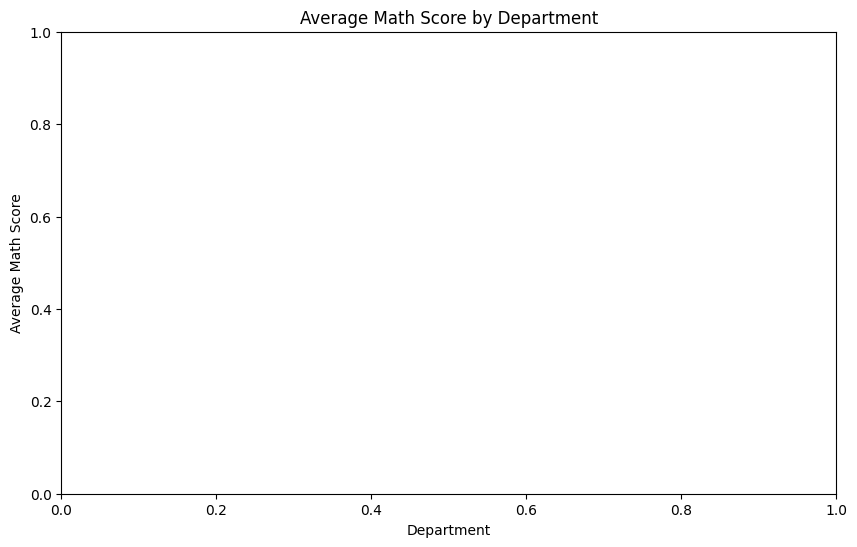

In [ ]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
ax.set_title('Average Math Score by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
plt.show()

